# Explainability Proof-of-Concept (POC): SHAP & LIME (Multi-Class)

This notebook demonstrates how to interpret the project's models (XGBoost on Latent Space $Z$) using SHAP and LIME for all three crash severity classes.

### Objectives
1. **Global Importance**: Which latent dimensions drive predictions for PDO, Injury, and Fatal?
2. **Local Deep-Dive**: Why was a specific crash flagged for each class?
3. **Physical Correlation**: Mapping abstract $Z$ dimensions back to original crash features.

In [1]:
import pickle
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from lime import lime_tabular

# Load data and model
Z_test = np.load("../data/processed/Z_test.npy")
y_test = np.load("../data/processed/y_test.npy")
with open("../models/best_ml_model.pkl", "rb") as f:
    model = pickle.load(f)

class_names = ["PDO", "Injury", "Fatal"]
print(f"Loaded Z_test with shape {Z_test.shape}")

Loaded Z_test with shape (14862, 32)


## 1. Global Explanations with SHAP
We use Permutation Explainer for all three classes.

PermutationExplainer explainer:  29%|████████████████████████▋                                                           | 147/500 [00:00<?, ?it/s]

PermutationExplainer explainer:  30%|██████████████████████▉                                                     | 151/500 [00:10<00:09, 35.41it/s]

PermutationExplainer explainer:  31%|███████████████████████▌                                                    | 155/500 [00:10<00:11, 30.77it/s]

PermutationExplainer explainer:  32%|████████████████████████▏                                                   | 159/500 [00:10<00:11, 28.77it/s]

PermutationExplainer explainer:  32%|████████████████████████▌                                                   | 162/500 [00:10<00:12, 27.71it/s]

...

PermutationExplainer explainer: 100%|███████████████████████████████████████████████████████████████████████████▋| 498/500 [00:22<00:00, 27.32it/s]

PermutationExplainer explainer: 501it [00:23, 26.98it/s]                                                                                           

PermutationExplainer explainer: 501it [00:23, 15.32it/s]


C:\Users\loren\AppData\Local\Temp\ipykernel_27500\4290604.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], Z_test[:500], feature_names=[f"Z_{i}" for i in range(Z_test.shape[1])], show=False)


Generating SHAP Summary Plots for all classes...
Summary Plot for PDO


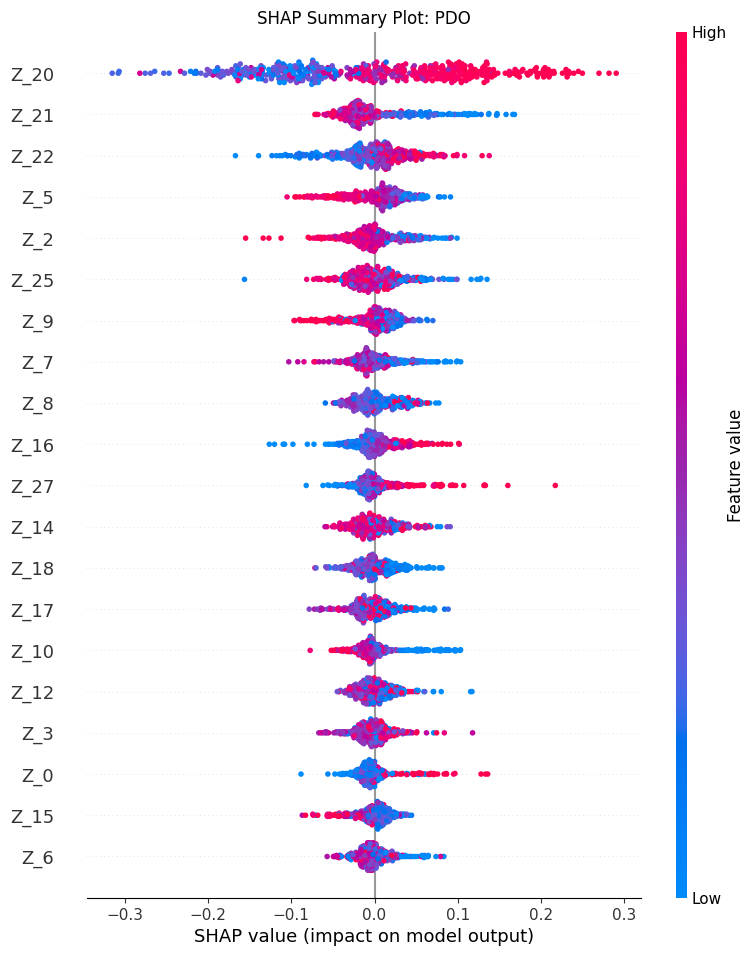

Summary Plot for Injury


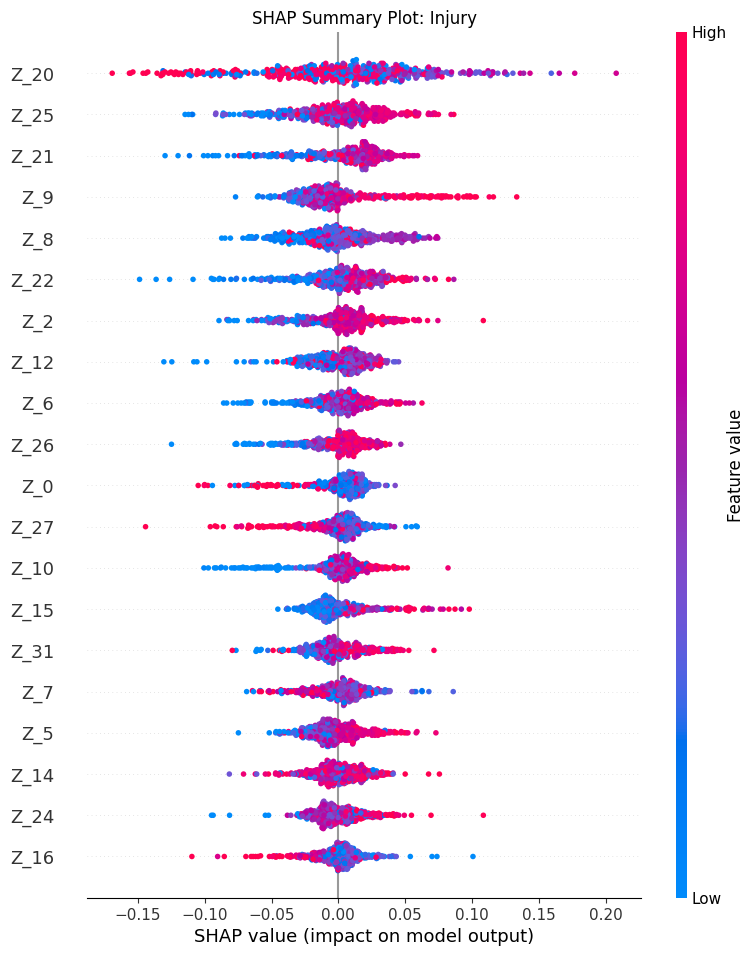

Summary Plot for Fatal


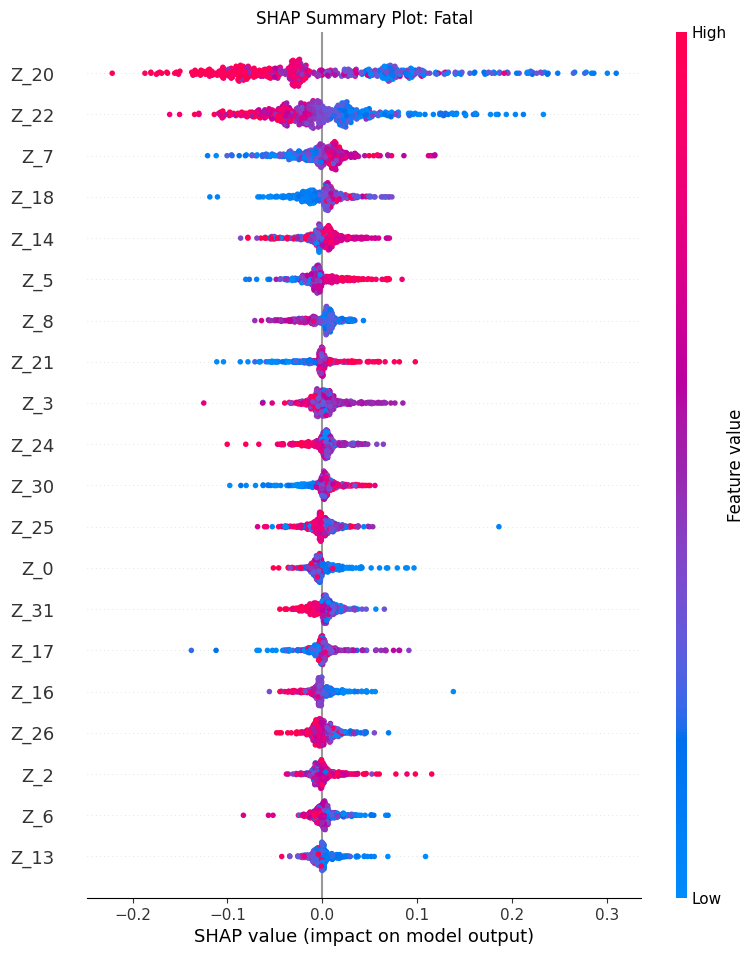

In [2]:
explainer = shap.Explainer(model.predict_proba, Z_test[:100])
shap_values = explainer(Z_test[:500])

print("Generating SHAP Summary Plots for all classes...")
for i, class_name in enumerate(class_names):
    plt.figure()
    print(f"Summary Plot for {class_name}")
    shap.summary_plot(shap_values[:, :, i], Z_test[:500], feature_names=[f"Z_{i}" for i in range(Z_test.shape[1])], show=False)
    plt.title(f"SHAP Summary Plot: {class_name}")
    plt.show()

## 2. Local Explanations with LIME
LIME explanation for all three classes for a single instance.

In [3]:
# Find a Fatal case
fatal_indices = np.where(y_test == 2)[0]
idx = fatal_indices[0]

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=Z_test, 
    feature_names=[f"Z_{i}" for i in range(Z_test.shape[1])],
    class_names=class_names,
    mode="classification"
)

exp = lime_explainer.explain_instance(Z_test[idx], model.predict_proba, num_features=5, labels=(0, 1, 2))
print(f"Explanation for test instance {idx} (True Class: {class_names[y_test[idx]]})")
for i, class_name in enumerate(class_names):
    print(f"\nLIME Explanation (Top 5 features for '{class_name}'):")
    for feature, weight in exp.as_list(label=i):
        print(f"  {feature}: {weight:.4f}")

Explanation for test instance 855 (True Class: Fatal)

LIME Explanation (Top 5 features for 'PDO'):
  Z_22 <= -0.44: -0.0653
  -0.80 < Z_20 <= 0.67: -0.0611
  -0.02 < Z_21 <= 0.06: -0.0407
  Z_16 > 0.02: 0.0375
  Z_0 > 0.09: 0.0371

LIME Explanation (Top 5 features for 'Injury'):
  -0.80 < Z_20 <= 0.67: 0.0620
  -0.02 < Z_21 <= 0.06: 0.0335
  Z_8 <= -0.08: -0.0334
  Z_15 > 0.06: 0.0271
  Z_16 > 0.02: -0.0254

LIME Explanation (Top 5 features for 'Fatal'):
  Z_22 <= -0.44: 0.0873
  Z_7 <= -0.05: -0.0355
  Z_8 <= -0.08: 0.0288
  Z_26 <= -0.07: 0.0240
  -0.05 < Z_18 <= 0.02: 0.0223


## 3. Mapping Latent $Z$ to Physical Features $X$

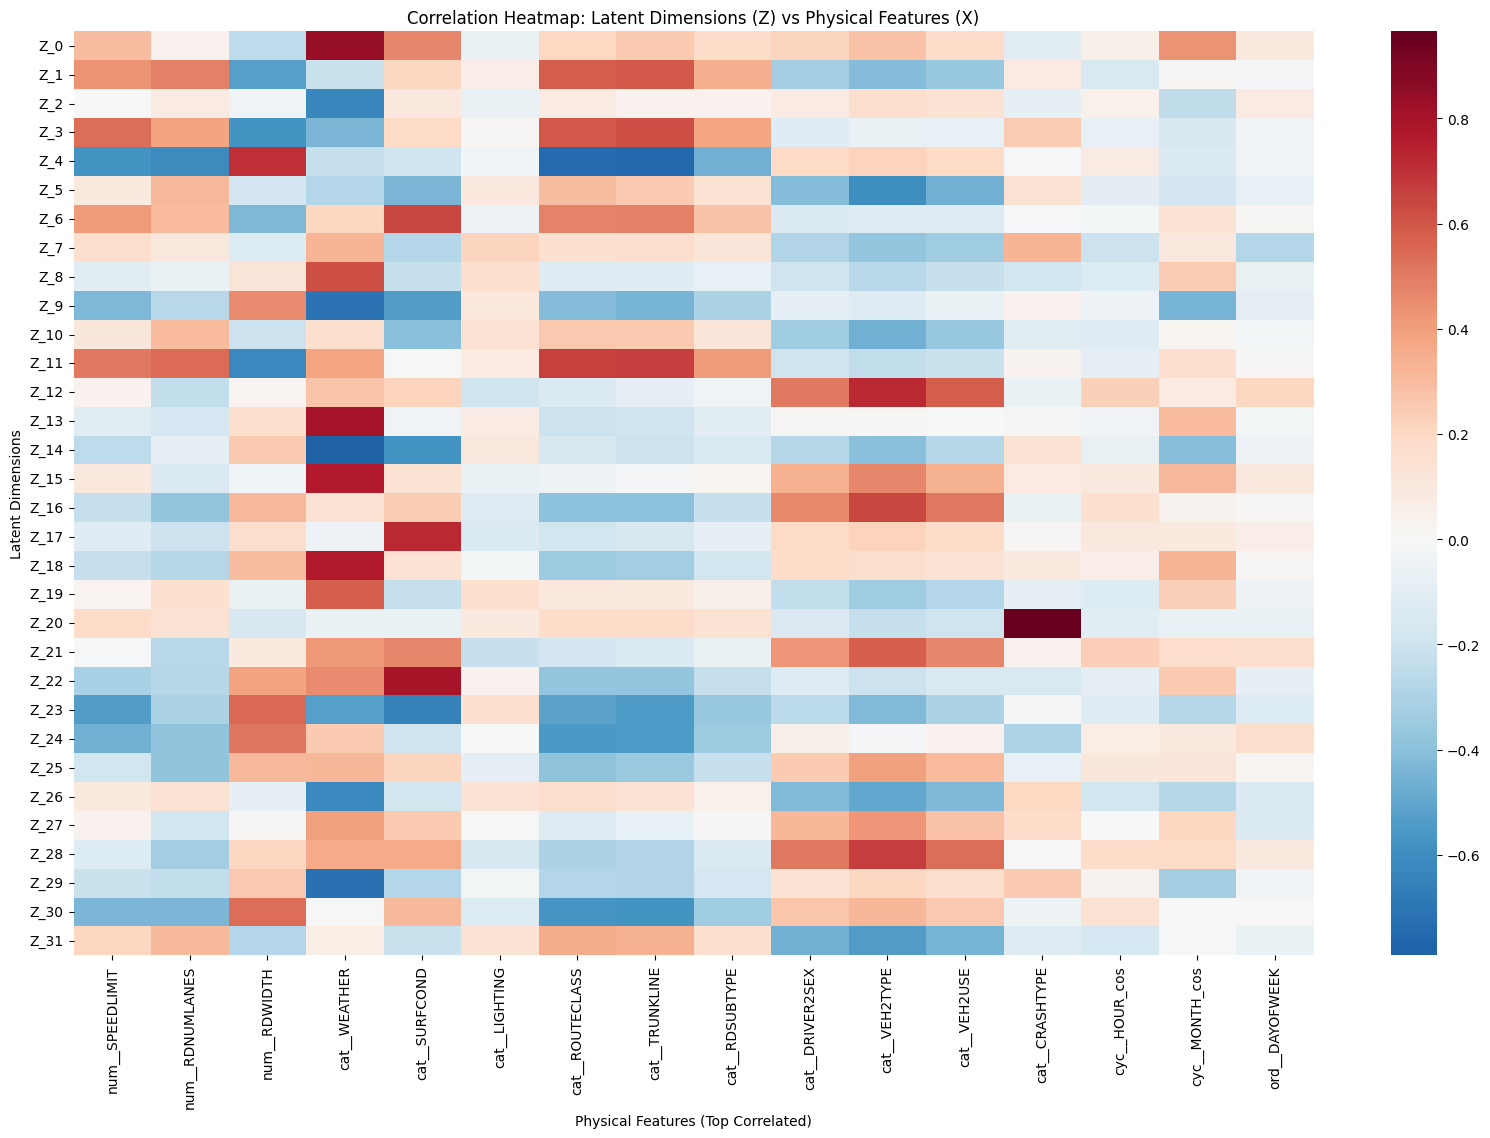

Top Correlations Summary Table:


,Latent_Dim,Top_Physical_Feature,Correlation
20,Z_20,cat__CRASHTYPE,0.965629
0,Z_0,cat__WEATHER,0.841938
13,Z_13,cat__WEATHER,0.804616
22,Z_22,cat__SURFCOND,0.790505
18,Z_18,cat__WEATHER,0.773314
15,Z_15,cat__WEATHER,0.771217
17,Z_17,cat__SURFCOND,0.728564
12,Z_12,cat__VEH2TYPE,0.728469
28,Z_28,cat__VEH2TYPE,0.668111
11,Z_11,cat__TRUNKLINE,0.665686



4. Training Global Surrogate Model (Decision Tree Proxy)...
Surrogate Model Accuracy (Fidelity to complex model): 0.6981563719553223

Extracted 'If-Then' Rules from Surrogate Model:
|--- Z_20 <= -0.46
|   |--- Z_0 <= 0.28
|   |   |--- Z_31 <= 0.13
|   |   |   |--- class: 2
|   |   |--- Z_31 >  0.13
|   |   |   |--- class: 1
|   |--- Z_0 >  0.28
|   |   |--- Z_24 <= -0.14
|   |   |   |--- class: 1
|   |   |--- Z_24 >  -0.14
|   |   |   |--- class: 0
|--- Z_20 >  -0.46
|   |--- Z_4 <= -0.33
|   |   |--- Z_15 <= -0.16
|   |   |   |--- class: 1
|   |   |--- Z_15 >  -0.16
|   |   |   |--- class: 0
|   |--- Z_4 >  -0.33
|   |   |--- Z_14 <= 0.10
|   |   |   |--- class: 0
|   |   |--- Z_14 >  0.10
|   |   |   |--- class: 0



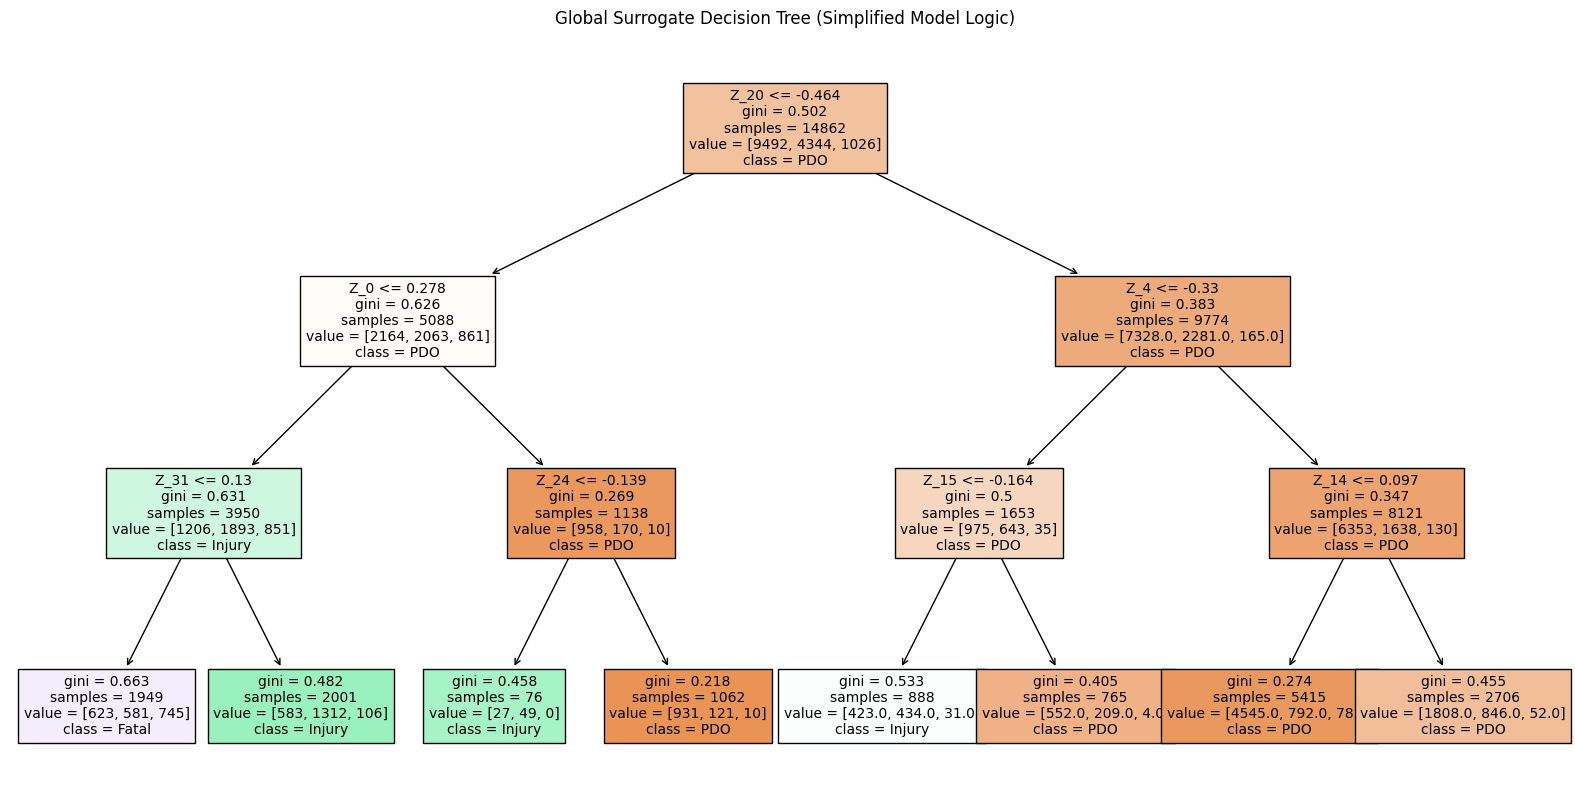

In [4]:
import seaborn as sns

# Load preprocessed X_test and feature names
X_test_scaled = np.load("../data/processed/X_test.npy")
with open("../models/preprocessing_pipeline.joblib", "rb") as f:
    import joblib
    pipeline = joblib.load(f)
    feature_names = pipeline.get_feature_names_out()

# Calculate full correlation matrix between Z and X
z_x_corr_matrix = np.zeros((Z_test.shape[1], X_test_scaled.shape[1]))
for i in range(Z_test.shape[1]):
    for j in range(X_test_scaled.shape[1]):
        # Handle constant features to avoid NaNs
        if np.std(X_test_scaled[:, j]) > 0 and np.std(Z_test[:, i]) > 0:
            z_x_corr_matrix[i, j] = np.corrcoef(Z_test[:, i], X_test_scaled[:, j])[0, 1]

# Filter features with at least some correlation to make the heatmap readable
max_corr_per_feat = np.max(np.abs(z_x_corr_matrix), axis=0)
relevant_feats_idx = np.where(max_corr_per_feat > 0.2)[0] # Show features with > 0.2 correlation

plt.figure(figsize=(20, 12))
sns.heatmap(
    z_x_corr_matrix[:, relevant_feats_idx], 
    xticklabels=feature_names[relevant_feats_idx], 
    yticklabels=[f"Z_{i}" for i in range(Z_test.shape[1])],
    cmap="RdBu_r", 
    center=0,
    annot=False
)
plt.title("Correlation Heatmap: Latent Dimensions (Z) vs Physical Features (X)")
plt.xlabel("Physical Features (Top Correlated)")
plt.ylabel("Latent Dimensions")
plt.show()

# Print top 10 mapping table
correlations = []
for i in range(Z_test.shape[1]):
    top_feat_idx = np.argmax(np.abs(z_x_corr_matrix[i, :]))
    correlations.append({
        "Latent_Dim": f"Z_{i}",
        "Top_Physical_Feature": feature_names[top_feat_idx],
        "Correlation": z_x_corr_matrix[i, top_feat_idx]
    })

corr_df = pd.DataFrame(correlations).sort_values("Correlation", ascending=False)
print("Top Correlations Summary Table:")
display(corr_df.head(10))

# --- 4. Global Surrogate Model ---
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

print("\n4. Training Global Surrogate Model (Decision Tree Proxy)...")
# Use the complex model's predictions as the 'target' for our simple surrogate
y_proxy = model.predict(Z_test)

surrogate = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate.fit(Z_test, y_proxy)

print("Surrogate Model Accuracy (Fidelity to complex model):", surrogate.score(Z_test, y_proxy))

print("\nExtracted 'If-Then' Rules from Surrogate Model:")
tree_rules = export_text(surrogate, feature_names=[f"Z_{i}" for i in range(Z_test.shape[1])])
print(tree_rules)

plt.figure(figsize=(20,10))
plot_tree(surrogate, feature_names=[f"Z_{i}" for i in range(Z_test.shape[1])], class_names=class_names, filled=True, fontsize=10)
plt.title("Global Surrogate Decision Tree (Simplified Model Logic)")
plt.show()